In [1]:
import casacore.tables as ct
import matplotlib.pyplot as plt, numpy as np

from matplotlib.colors import LogNorm
from astropy import time

In [2]:
ms_file = '/scratch/snx3000/mibianco/output_sdc3/dataLC_130923/ms/lc_256_train_130923_i0_dT_ch600_4h1d_256.MS'
ms = ct.table(ms_file, readonly=True, ack=False)

In [3]:
# Get the time and antenna1/antenna2 columns
time = ms.getcol('TIME')
ant1 = ms.getcol('ANTENNA1')
ant2 = ms.getcol('ANTENNA2')

In [4]:
# Get the frequency data from the SPECTRAL_WINDOW subtable
spw_table = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
frequency = spw_table.getcol('CHAN_FREQ')
print(frequency)

# Get the unique antenna IDs and number of antennas
antennas = np.unique(np.concatenate((ant1, ant2)))
num_antennas = len(antennas)
print('Number of antennas: ', num_antennas)

# access the ANTENNA table and get antenna XYZ-coordinates
xyz_coord = ms.ANTENNA.getcol('POSITION')

# Get the number of time steps and baselines
num_times = len(np.unique(time))
num_baselines = int(num_antennas * (num_antennas - 1) / 2)


# Get the number of time steps and baselines
num_times = len(np.unique(time))
num_baselines = int(num_antennas * (num_antennas - 1) / 2)


[[1.66e+08]]
Number of antennas:  512


In [25]:
# Get the UVW and Visibility data for all rows in the MS
uvw_data = ms.getcol('UVW')
vis_data = ms.getcol('DATA')

print(vis_data.shape)

# Reshape the UVW and Visibility data into a (N_time, N_baseline, 3) array
uvw = uvw_data.reshape(num_times, num_baselines, 3)
vis_data = vis_data.reshape(num_times, num_baselines, 1, 4)

print("uvw shape: ", uvw.shape)
print("vis_data shape: ", vis_data.shape)

# Close the MeasurementSet
spw_table.close()
ms.close()

print(uvw_data.shape)

(188375040, 1, 4)
uvw shape:  (1440, 130816, 3)
vis_data shape:  (1440, 130816, 1, 4)
(188375040, 3)


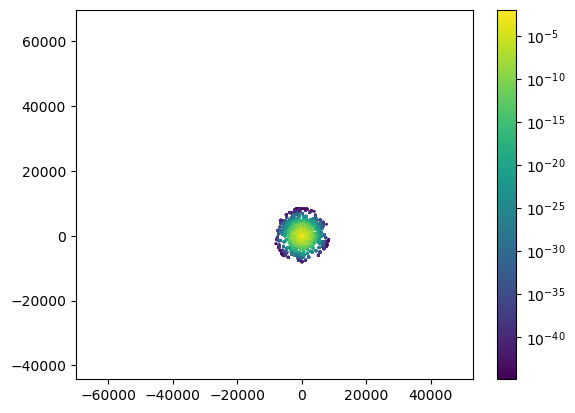

In [26]:
i_time = 200
plt.scatter(x=uvw[i_time,:,0], y=uvw[i_time,:,1], c=vis_data[i_time,:,0,0].real, s=1, norm='log')
plt.colorbar()